<a href="https://colab.research.google.com/github/ancantos99/proyectointegrador_ia_grupo8/blob/main/notebooks/05_evaluacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#ENTRENAMIENTO DEL MODELO Y EVALUACIÓN

In [ ]:
# Clonar el repo del dataset en /content/dataset
!git lfs install > /dev/null 2>&1
!git clone https://huggingface.co/datasets/YashJain/UI-Elements-Detection-Dataset /content/dataset > /dev/null 2>&1
print("✅ Git LFS instalado y el dataset clonado en '/content/dataset' de forma silenciosa.")

✅ Git LFS instalado y el dataset clonado en '/content/dataset' de forma silenciosa.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Instarlar librerias
!pip install ultralytics > /dev/null 2>&1
print("✅ Ultralytics instalado de forma silenciosa")

✅ Ultralytics instalado de forma silenciosa


In [ ]:
#Descargo librerias propias
import os
os.makedirs("/content/tools", exist_ok=True)
!wget -q https://raw.githubusercontent.com/ancantos99/proyectointegrador_ia_grupo8/refs/heads/main/src/tools/YOLODatasetManager.py -O /content/tools/YOLODatasetManager.py > /dev/null 2>&1
!wget -q https://raw.githubusercontent.com/ancantos99/proyectointegrador_ia_grupo8/refs/heads/main/src/tools/YOLOMetricasVisualizar.py -O /content/tools/YOLOMetricasVisualizar.py > /dev/null 2>&1
!wget https://raw.githubusercontent.com/ancantos99/proyectointegrador_ia_grupo8/refs/heads/main/src/data_processing.py -O /content/tools/data_processing.py > /dev/null 2>&1
import importlib
import logging
import sys
sys.path.append("/content/tools")
import YOLODatasetManager
import YOLOMetricasVisualizar
import data_processing
#Recarga de archivos - Para actualizar al último Push
importlib.reload(YOLODatasetManager)
importlib.reload(YOLOMetricasVisualizar)
importlib.reload(data_processing)
from YOLODatasetManager import YOLODatasetManager
from YOLOMetricasVisualizar import YOLOMetricasVisualizar
from data_processing import Data_processing
# Configuración global del Login
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(name)s - %(levelname)s - %(message)s', force=True )

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
datasetmanager = YOLODatasetManager("/content/dataset")
datasetmanager.yaml_cambiar_carpeta(split="train",nuevaruta="train")
counts = datasetmanager.compute_class_distribution("train")
print("Distribución:", counts)
##datasetmanager.plot_distribution()

2025-10-22 23:50:42,243 - YOLODatasetManager - INFO - Ruta Split train actualizada correctamente a train/images en /content/dataset/dataset.yaml.


Distribución: {'0': 15583, '1': 5101, '2': 354, '3': 0, '4': 26, '5': 1032, '6': 42, '7': 54, '8': 799, '9': 15, '10': 8, '11': 820, '12': 23, '13': 141, '14': 0, '15': 0}


# APLICAR SOBREMUESTREO

In [ ]:
processor = Data_processing(datasetmanager.ruta_raiz_dataset)
antes = processor.count_class_distribution("Antes")
processor.oversample_rare_classes();


Distribución Detallada de Clases Antes:
  ID Clase                   Train      Val     Test    Total  % Total
--------------------------------------------------------------------------------
   0 link                    15583     1563     2222    19368    64.48%
   1 button                   5101      627      877     6605    21.99%
   2 input                     354       54       44      452     1.50%
   3 select                      0        0        0        0     0.00%
   4 textarea                   26        8        3       37     0.12%
   5 label                    1032       59       37     1128     3.76%
   6 checkbox                   42        0        9       51     0.17%
   7 radio                      54        6       16       76     0.25%
   8 dropdown                  799       88       93      980     3.26%
   9 slider                     15        2        1       18     0.06%
  10 toggle                      8        0        0        8     0.03%
  11 menu_item 

In [ ]:
despues = processor.count_class_distribution("Despues")



Distribución Detallada de Clases Despues:
  ID Clase                   Train      Val     Test    Total  % Total
--------------------------------------------------------------------------------
   0 link                    36683     1563     2222    40468    64.92%
   1 button                  10961      627      877    12465    20.00%
   2 input                    1074       54       44     1172     1.88%
   3 select                      0        0        0        0     0.00%
   4 textarea                  286        8        3      297     0.48%
   5 label                    2552       59       37     2648     4.25%
   6 checkbox                  462        0        9      471     0.76%
   7 radio                     594        6       16      616     0.99%
   8 dropdown                 1389       88       93     1570     2.52%
   9 slider                    165        2        1      168     0.27%
  10 toggle                     88        0        0       88     0.14%
  11 menu_ite

## 3️⃣ **Entrenamiento del modelo**


In [ ]:
from ultralytics import YOLO
datasetmanager.yaml_cambiar_carpeta(split="train",nuevaruta="train")
#Entrenar YOLO de manera clásica con el dataset train, para eso modifico la ruta en el dataset.yaml
model = YOLO("yolov8l.pt")  # yolov8l.pt.
# Cargar dataset usando YOLOv8 Dataset
carpeta_salida = "exp_5" #carpeta donde se van a guardar los resultados del entrenamiento de YOLO y el modelo
model.train(data=datasetmanager.ruta_yaml,
    epochs=100,         #epocas 100
    imgsz= (1920,1080), #tamaño a los que se redimensionara la imagen de entrada #(1920,1080) - 640
    batch=6,            #tamaño del batch (ajustarlo según Vram)
    optimizer="AdamW", #AdamW
    #momentum =0.72765,      # será ignorado si usa Adam/AdamW
    weight_decay = 0.00808107114573286,
    lr0= 0.00004694921598565255,
    lrf= 0.46315,
    name= carpeta_salida,   # nombre del run
    exist_ok=False,         # sobrescribe si ya existe
    project="/content/drive/MyDrive/MIA/Entrenamientos", #En Drive
    patience=15
)

2025-10-23 00:00:06,592 - YOLODatasetManager - INFO - Ruta Split train actualizada correctamente a train/images en /content/dataset/dataset.yaml.


Ultralytics 8.3.220 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=6, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=(1920, 1080), int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=4.694921598565255e-05, lrf=0.46315, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8l.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=exp_5, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patie

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  4,  5,  7,  8,  9, 11, 12, 13])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b371bd9acc0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.

## 4️⃣ **Generación de todas las curvas y Evaluación**

In [ ]:
# Crear objeto Visualizador
carpeta_salida = "exp_5"
visualizer = YOLOMetricasVisualizar(f"/content/drive/MyDrive/MIA/Entrenamientos/{carpeta_salida}/results.csv",
                                    f"/content/drive/MyDrive/MIA/Entrenamientos/{carpeta_salida}/weights/best.pt",datasetmanager.ruta_yaml)

Ultralytics 8.3.220 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
Model summary (fused): 112 layers, 43,618,944 parameters, 0 gradients, 164.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3042.7±1723.8 MB/s, size: 698.3 KB)
val: Scanning /content/dataset/val/labels.cache... 71 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 71/71 139.3Kit/s 0.0s
val: /content/dataset/val/images/dev_tools_jsfiddle.net_1729629915.png: 5 duplicate labels removed
val: /content/dataset/val/images/development_developer.mozilla.org_1729626875.png: 3 duplicate labels removed
val: /content/dataset/val/images/development_developer.mozilla.org_1729629644.png: 3 duplicate labels removed
val: /content/dataset/val/images/e_commerce_www.amazon.com_1729629595.png: 4 duplicate labels removed
val: /content/dataset/val/images/microsoft_office_www.office.com_1729629719.png: 1 duplicate labels removed
val: /content/dataset/val/images/mostvisited_amazon.co.jp_1729630376.png: 5 d

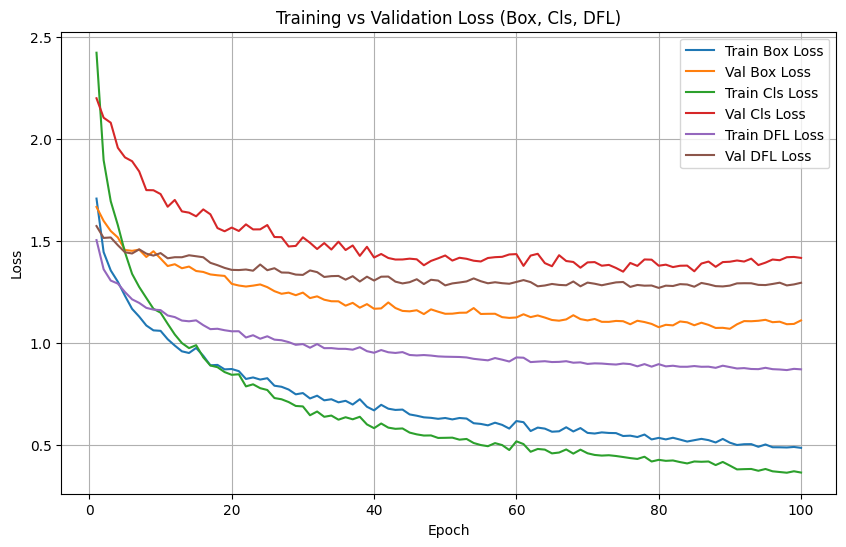

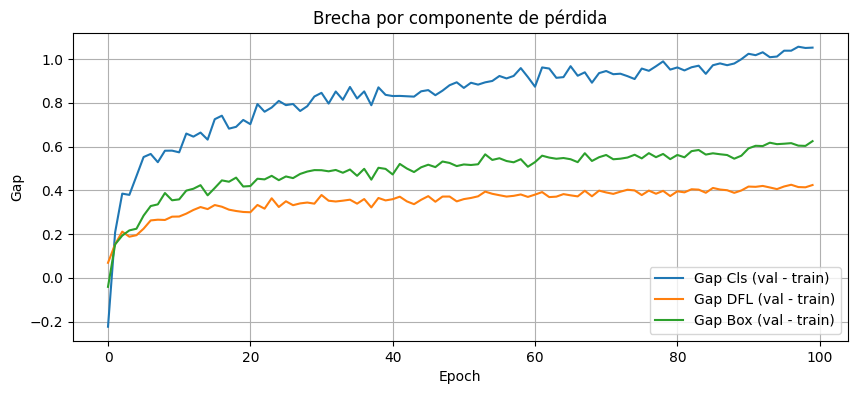

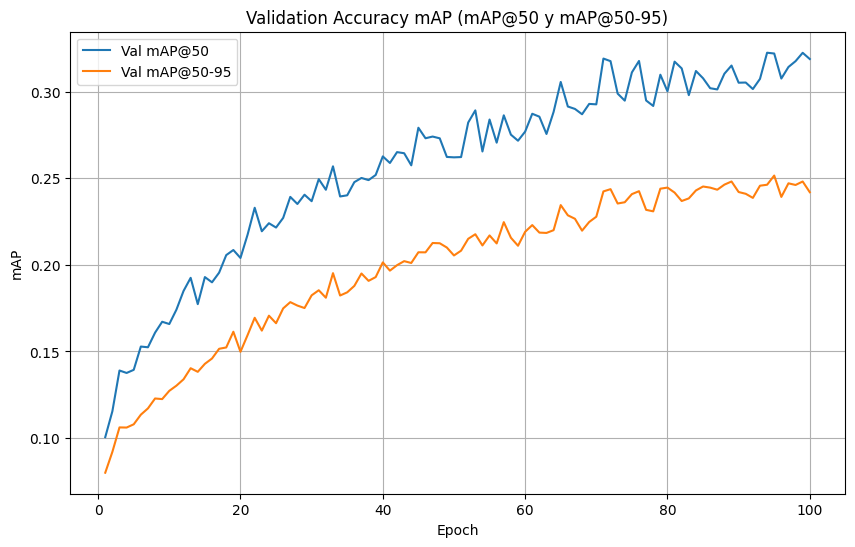

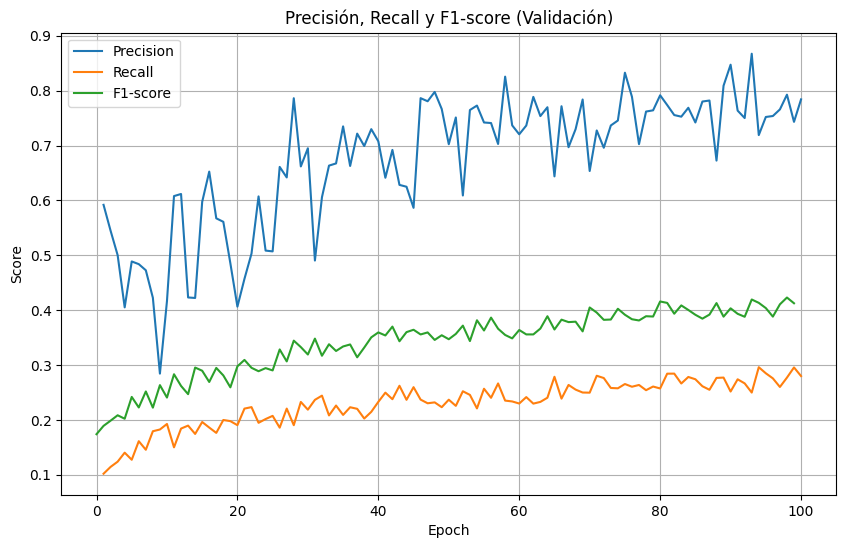

Final Metrics (last epoch):
Precision: 0.7840
Recall:    0.2800
F1-score:  0.4126


,Clase,Precision,Recall,F1,mAP50
0,link,0.684501,0.588044,0.632617,0.595767
1,button,0.761866,0.5506,0.63923,0.608736
2,input,0.92855,0.721998,0.81235,0.761903
3,select,clase sin métricas,clase sin métricas,clase sin métricas,clase sin métricas
4,textarea,0.75163,0.375,0.500362,0.479878
5,label,0.699359,0.474576,0.565447,0.52422
6,checkbox,clase sin métricas,clase sin métricas,clase sin métricas,clase sin métricas
7,radio,1.0,0.0,0.0,0.0
8,dropdown,0.727023,0.291139,0.415778,0.33664
9,slider,1.0,0.0,0.0,0.0


In [ ]:
visualizer.plot_loss() # Graficar Loss
visualizer.gap_entretrainyval() # Graficar Gap
visualizer.plot_map()  # Graficar mAP
visualizer.plot_precision_recall_f1() # Graficar Precision, Recall, F1
visualizer.print_final_metrics() # Mostrar métricas finales
#Metricas por Clase
df = visualizer.metrics_por_clase_tabla()   # Imprime Precision, Recall, F1 y mAP50 por clase
display(df)


image 1/1 /content/drive/MyDrive/MIA/webs_prueba/web_senescyt.png: 928x1920 4 links, 3 buttons, 1 input, 156.2ms
Speed: 10.1ms preprocess, 156.2ms inference, 4.2ms postprocess per image at shape (1, 3, 928, 1920)


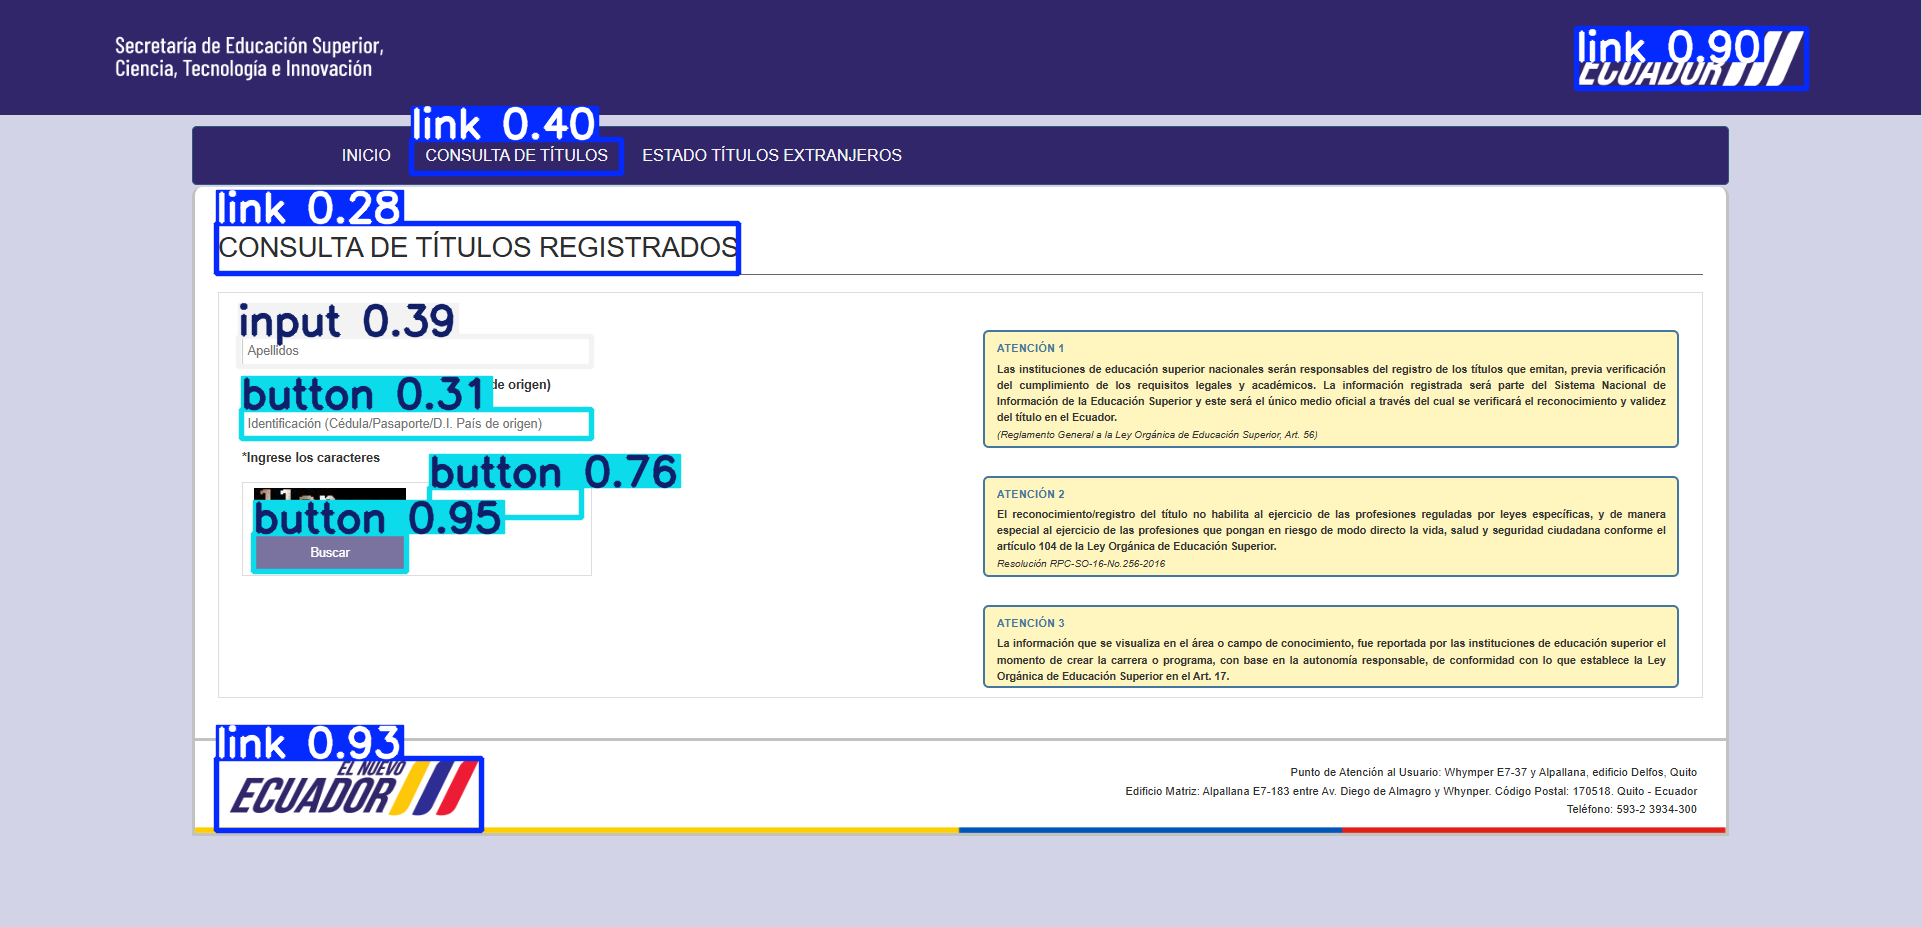

In [ ]:
from ultralytics import YOLO
import cv2
from PIL import Image
from matplotlib import pyplot as plt

ruta_modelo = "/content/drive/MyDrive/MIA/Entrenamientos/exp_5/weights/best.pt"
ruta_imagen = "/content/drive/MyDrive/MIA/webs_prueba/web_senescyt.png";

model = YOLO(ruta_modelo)
results = model.predict(ruta_imagen,conf=0.35)
res = results[0] if isinstance(results, list) else results
res.show()



image 1/1 /content/drive/MyDrive/MIA/webs_prueba/web_senescyt.png: 928x1920 6 links, 4 buttons, 1 input, 158.9ms
Speed: 9.7ms preprocess, 158.9ms inference, 5.5ms postprocess per image at shape (1, 3, 928, 1920)


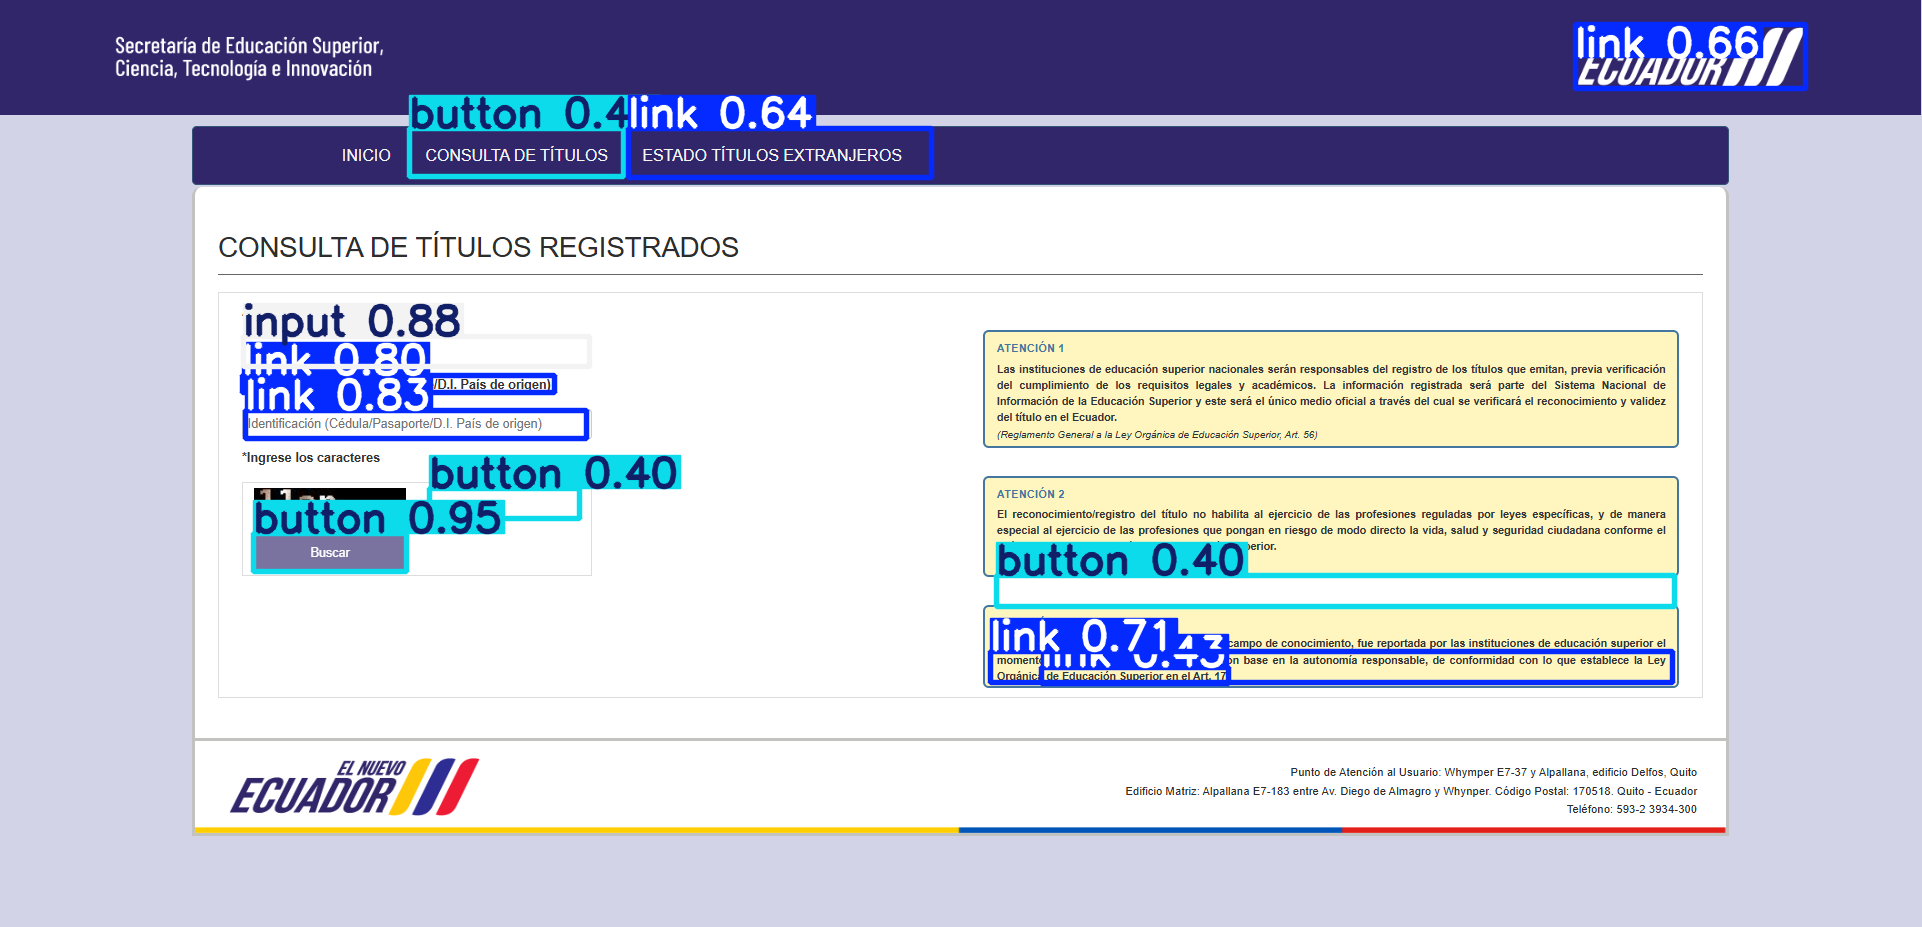

In [ ]:
ruta_modelo = "/content/drive/MyDrive/MIA/Entrenamientos/exp_4_1/weights/best.pt"
ruta_imagen = "/content/drive/MyDrive/MIA/webs_prueba/web_senescyt.png";

model = YOLO(ruta_modelo)
results = model.predict(ruta_imagen,conf=0.35)
res = results[0] if isinstance(results, list) else results
res.show()